In [1]:
import sys
sys.path.append('..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use('default')
sns.set_palette("husl")
print("Setup complete!")

Setup complete!


# Nigeria (Lagos) - Climate Data Analysis

**Station:** Lagos | **Elevation:** Sea level | **Period:** 2015-2026

Lagos is a coastal megacity on the Gulf of Guinea (Atlantic Ocean). Its 
tropical climate features warm temperatures year-round, high humidity, 
and distinct wet and dry seasons driven by the West African Monsoon.

In [2]:
df = pd.read_csv('../data/nigeria.csv')
df['Country'] = 'Nigeria'
df['Date'] = pd.to_datetime(df['YEAR'] * 1000 + df['DOY'], format='%Y%j')
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df.replace(-999, np.nan, inplace=True)

print(f"Shape: {df.shape}")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
df.head()

Shape: (4108, 16)
Date range: 2015-01-01 to 2026-03-31


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month,Year
0,2015,1,25.23,29.25,22.06,7.19,0.0,68.26,1.73,2.61,100.86,13.36,Nigeria,2015-01-01,1,2015
1,2015,2,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37,Nigeria,2015-01-02,1,2015
2,2015,3,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98,Nigeria,2015-01-03,1,2015
3,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65,Nigeria,2015-01-04,1,2015
4,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40,Nigeria,2015-01-05,1,2015


In [3]:
missing = df.isna().sum()
missing_pct = (missing / len(df)) * 100
print("Missing values (>0%):")
print(missing_pct[missing_pct > 0])
print(f"\nDuplicate rows: {df.duplicated().sum()}")

Missing values (>0%):
Series([], dtype: float64)

Duplicate rows: 0


In [4]:
df_clean = df.copy()
weather_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 
                'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M']
df_clean[weather_cols] = df_clean[weather_cols].ffill()
df_clean.to_csv('../data/nigeria_clean.csv', index=False)
print("Cleaned data saved!")


Cleaned data saved!


In [5]:
print("NIGERIA TEMPERATURE SUMMARY")
print(f"Mean T2M: {df_clean['T2M'].mean():.1f} C")
print(f"Max T2M: {df_clean['T2M'].max():.1f} C")
print(f"Min T2M: {df_clean['T2M'].min():.1f} C")
print(f"Std Dev: {df_clean['T2M'].std():.1f} C")
print(f"Mean Daily Range: {df_clean['T2M_RANGE'].mean():.1f} C")

heat_days = (df_clean['T2M_MAX'] > 35).sum()
heat_days_40 = (df_clean['T2M_MAX'] > 40).sum()
print(f"Days T2M_MAX > 35C: {heat_days} ({heat_days/len(df_clean)*100:.1f}%)")
print(f"Days T2M_MAX > 40C: {heat_days_40}")

NIGERIA TEMPERATURE SUMMARY
Mean T2M: 26.7 C
Max T2M: 29.3 C
Min T2M: 21.1 C
Std Dev: 1.1 C
Mean Daily Range: 4.0 C
Days T2M_MAX > 35C: 0 (0.0%)
Days T2M_MAX > 40C: 0


**Temperature Observations:**

Lagos has a hot tropical climate with consistently warm temperatures year-round. 
The low diurnal temperature range reflects the moderating influence of the 
Atlantic Ocean and high humidity levels. Unlike continental locations, coastal 
Lagos experiences minimal seasonal temperature variation.

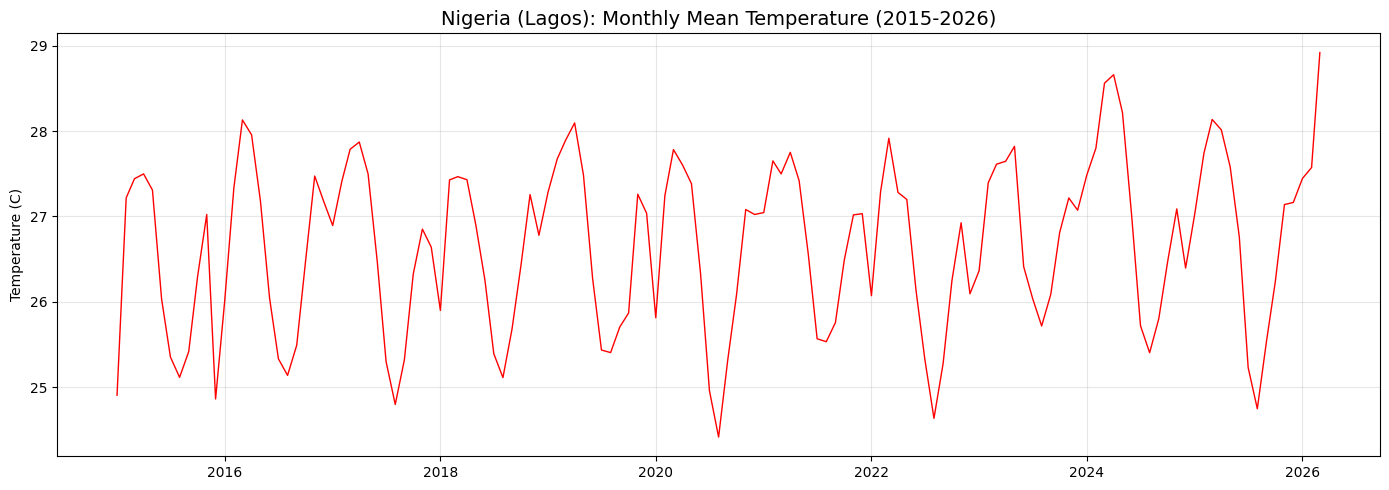

In [6]:
monthly_temp = df_clean.groupby(['Year', 'Month'])['T2M'].mean().reset_index()
monthly_temp['Date'] = pd.to_datetime(monthly_temp[['Year', 'Month']].assign(Day=1))

plt.figure(figsize=(14, 5))
plt.plot(monthly_temp['Date'], monthly_temp['T2M'], 'r-', linewidth=1)
plt.title('Nigeria (Lagos): Monthly Mean Temperature (2015-2026)', fontsize=14)
plt.ylabel('Temperature (C)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()